Setup and Feature Selection

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("Churn.csv")

# Features chosen for segmentation — behavioral/financial, not the churn label itself
# Excluding Exited, Complain, Satisfaction Score on purpose: clustering should describe
# who the customer IS, not reference the outcome we're trying to explain
cluster_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 
                     'NumOfProducts', 'EstimatedSalary', 'IsActiveMember']

X = df[cluster_features]

Scale the features

In [3]:
# K-Means uses distance between points — features on very different scales
# (e.g. Balance in the 100,000s vs Tenure 0-10) would otherwise dominate the result unfairly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Find the right number of clusters the Elbow Method

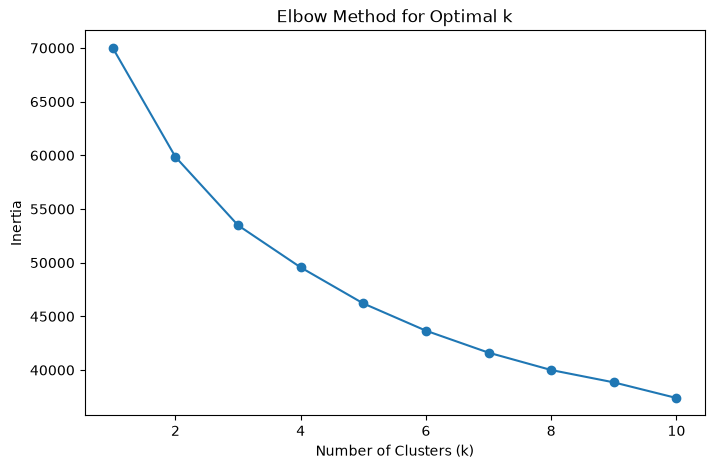

In [4]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Build the model with k=4 and then interpret what each cluster actually represents

In [5]:
# Build final clustering model with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Check cluster sizes
print(df['Cluster'].value_counts().sort_index())

Cluster
0    2876
1    2761
2    3247
3    1116
Name: count, dtype: int64


In [6]:
# Profile each cluster — average values per feature, plus churn rate
cluster_profile = df.groupby('Cluster')[cluster_features + ['Exited']].mean()
print(cluster_profile.round(2))

         CreditScore    Age  Tenure    Balance  NumOfProducts  \
Cluster                                                         
0             653.23  35.30    4.84  107773.22           1.29   
1             650.46  35.92    5.14    9540.17           2.13   
2             647.28  37.47    5.08  105903.15           1.27   
3             653.22  59.88    4.94   75891.74           1.43   

         EstimatedSalary  IsActiveMember  Exited  
Cluster                                           
0              100774.29            1.00    0.13  
1               99575.45            0.49    0.12  
2              101699.25            0.00    0.29  
3               94919.59            0.83    0.36  


Cluster 0 — "Engaged High-Balance" (2,876 customers, 13% churn — lowest risk)
High balance (~$108K), fully active (IsActiveMember = 1.00, meaning literally every customer here is active), average age, low product count. This is your healthiest, most stable segment — active engagement seems to be doing real protective work here.

Cluster 1 — "Multi-Product Low-Balance" (2,761 customers, 12% churn — lowest risk, tied with Cluster 0)
Very low balance (~$9.5K — likely the zero/near-zero balance segment we spotted back in EDA), but the highest product count (2.13) of any cluster, and roughly half active (0.49). Despite low balance, this group churns the least — reinforcing the Step 3/4 finding that 2 products is the "sweet spot" for loyalty, and that balance alone isn't protective.

Cluster 2 — "Disengaged High-Balance" (3,247 customers, 29% churn — high risk)
Similar balance to Cluster 0 (~$106K) and similar product count (1.27) — but zero active members (IsActiveMember = 0.00, literally everyone in this cluster is inactive). This is the sharpest contrast in the whole table: Cluster 0 and Cluster 2 look almost identical on balance and products, but activity status alone appears to more than double the churn rate (13% → 29%). This is a very clean, powerful illustration of IsActiveMember as a real driver.

Cluster 3 — "Older Moderate-Balance" (1,116 customers, 36% churn — highest risk)
Notably older (~60 vs ~35-37 for everyone else), moderate balance, mostly active (0.83) but still the highest churn rate of all four groups. This cluster essentially isolates the Age effect you found back in Step 3/4 — even with decent activity levels, this older segment churns most, confirming Age as a driver that persists even when engagement is controlled for.

The big story this table tells: Activity status (Cluster 0 vs 2) and Age (Cluster 3) look like the two strongest, cleanest churn separators once you group customers behaviorally — arguably clearer here than in the single-variable EDA, because clustering naturally controls for the other variables at the same time.